In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import plotly.graph_objects as go

In [5]:
def predPalPerCity(wtsl, xl, yl, packages, threshold):
    wts=np.array(wtsl)
    x=np.array(xl)
    y=np.array(yl)
    N = sum(wts)
    Sxy = sum(wts * x * y)
    Sx = sum(wts * x)
    Sy = sum(wts * y)
    Sxx = sum(wts * x * x)
    m = (N*Sxy - Sx * Sy)/ (N * Sxx - Sx ** 2)
    b = (Sy - m* Sx)/N
    dev = 0
    Sxxw = 0
    Xw = Sx / N
    for i, j, k in zip(wts, xl, yl):
        dev += i*(k - (m * packages + b))**2
        Sxxw += i * (j - Xw)**2
    dev = (dev / (N - 2)) ** .5
    dev_pred = dev * (1 + 1 / N + (packages - Xw)**2/Sxxw)**.5
    pred = m * packages + b
    z = (threshold - pred) / dev_pred
    prob = stats.norm.cdf(z)
    return pred, prob


In [6]:
predPalPerCity([17,16,15,14,13,12,11,10,9,8,7,6,5,4], [89935, 117350, 89602, 67356, 73218, 62623, 97485,91324,90908,97972,94140,99789,49875,104027], [45,50,38,32,41,31,45,48,44,48,40,39,26,49],67422,43)

(np.float64(34.34631248359705), np.float64(0.8101368281842358))

In [7]:
def graphData(wtsl, xl, yl):
    wts=np.array(wtsl)
    x=np.array(xl)
    y=np.array(yl)
    N = sum(wts)
    Sxy = sum(wts * x * y)
    Sx = sum(wts * x)
    Sy = sum(wts * y)
    Sxx = sum(wts * x * x)
    m = (N*Sxy - Sx * Sy)/ (N * Sxx - Sx ** 2)
    b = (Sy - m* Sx)/N
    y_pred = m * x + b
    
    fig = go.Figure()

    fig.add_trace(go.Scatter(
    x=x,
    y=y,
    mode="markers",
    name="Training data"
    ))

    fig.add_trace(go.Scatter(
    x=x,
    y=y_pred,
    mode="lines",
    name="Weighted regression"
    ))

    fig.update_layout(
    xaxis_title="Total Warehouse Package Count",
    yaxis_title="City Pallet Count"
    )

    fig.show()
    

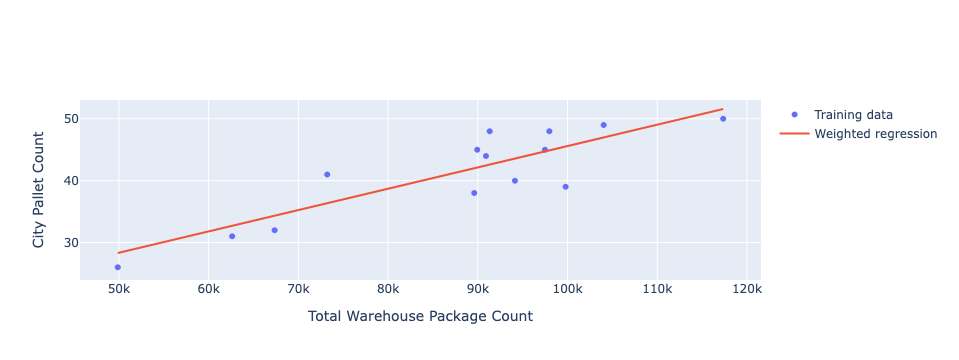

In [8]:
graphData([17,16,15,14,13,12,11,10,9,8,7,6,5,4], [89935, 117350, 89602, 67356, 73218, 62623, 97485,91324,90908,97972,94140,99789,49875,104027], [45,50,38,32,41,31,45,48,44,48,40,39,26,49])